In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import re
import os

sns.set_style("whitegrid")
os.makedirs("results", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [2]:
df = pd.read_csv("../data/clinvar_result.txt", sep="\t")

cols_to_remove = [
    "Somatic clinical impact",
    "Somatic clinical impact date last evaluated",
    "Somatic clinical impact review status",
    "Oncogenicity classification",
    "Oncogenicity date last evaluated",
    "Oncogenicity review status",
    "Unnamed: 24",
]
df = df.drop(columns=cols_to_remove)

print(f"Loaded {len(df)} OTOF variants from ClinVar.")

Loaded 2432 OTOF variants from ClinVar.


In [3]:
def extract_aa_position(name):
    if pd.isna(name):
        return np.nan
    # Look for patterns like "p.Arg963Ter" or "p.Met1858Val" or "p.Gly783AlafsTer17"
    match = re.search(r"p\.[A-Z][a-z]{2}(\d+)", str(name))
    if match:
        return int(match.group(1))
    return np.nan

df["aa_position"] = df["Name"].apply(extract_aa_position)

# How many variants have an extractable amino acid position?
mapped = df["aa_position"].notna().sum()
print(f"Variants with extractable amino acid position: {mapped} / {len(df)}")
print(f"\nRange of positions: {int(df['aa_position'].min())} to {int(df['aa_position'].max())}")

Variants with extractable amino acid position: 1600 / 2432

Range of positions: 2 to 1997


In [4]:
# Otoferlin protein domains (UniProt P52787, canonical isoform, 1997 aa)
# Domain boundaries from UniProt + literature on C2 domain architecture
PROTEIN_LENGTH = 1997

domains = [
    {"name": "C2A", "start": 1,    "end": 122,  "color": "#4C72B0"},
    {"name": "C2B", "start": 360,  "end": 480,  "color": "#55A868"},
    {"name": "C2C", "start": 481,  "end": 596,  "color": "#C44E52"},
    {"name": "C2D", "start": 940,  "end": 1054, "color": "#8172B2"},
    {"name": "C2E", "start": 1158, "end": 1273, "color": "#CCB974"},
    {"name": "C2F", "start": 1481, "end": 1597, "color": "#64B5CD"},
    {"name": "TM",  "start": 1942, "end": 1973, "color": "#777777"},
]

# Assign each variant to its domain (or "Linker" if outside)
def assign_domain(pos):
    if pd.isna(pos):
        return None
    for d in domains:
        if d["start"] <= pos <= d["end"]:
            return d["name"]
    return "Linker"

df["domain"] = df["aa_position"].apply(assign_domain)

# Count variants per domain
domain_counts = df["domain"].value_counts()
print("Variants per domain:")
print(domain_counts)

Variants per domain:
domain
Linker    1020
C2E        103
C2C         99
C2A         92
C2D         88
C2B         88
C2F         85
TM          25
Name: count, dtype: int64


In [5]:
pathogenic_classes = ["Pathogenic", "Likely pathogenic", "Pathogenic/Likely pathogenic"]
benign_classes = ["Benign", "Likely benign", "Benign/Likely benign"]
vus_classes = ["Uncertain significance", "Conflicting classifications of pathogenicity"]

def simplify_classification(cls):
    if cls in pathogenic_classes:
        return "Pathogenic"
    if cls in benign_classes:
        return "Benign"
    if cls in vus_classes:
        return "Uncertain"
    return "Other"

df["simplified_class"] = df["Germline classification"].apply(simplify_classification)

# Crosstab domain vs simplified class
domain_class_table = pd.crosstab(df["domain"], df["simplified_class"])
print("Variants by domain and classification:")
print(domain_class_table)

Variants by domain and classification:
simplified_class  Benign  Other  Pathogenic  Uncertain
domain                                                
C2A                   42      0           8         42
C2B                   37      3          20         28
C2C                   46      5          18         30
C2D                   38      0          18         32
C2E                   49      0          15         39
C2F                   34      1          15         35
Linker               419     17         158        426
TM                    13      0           3          9


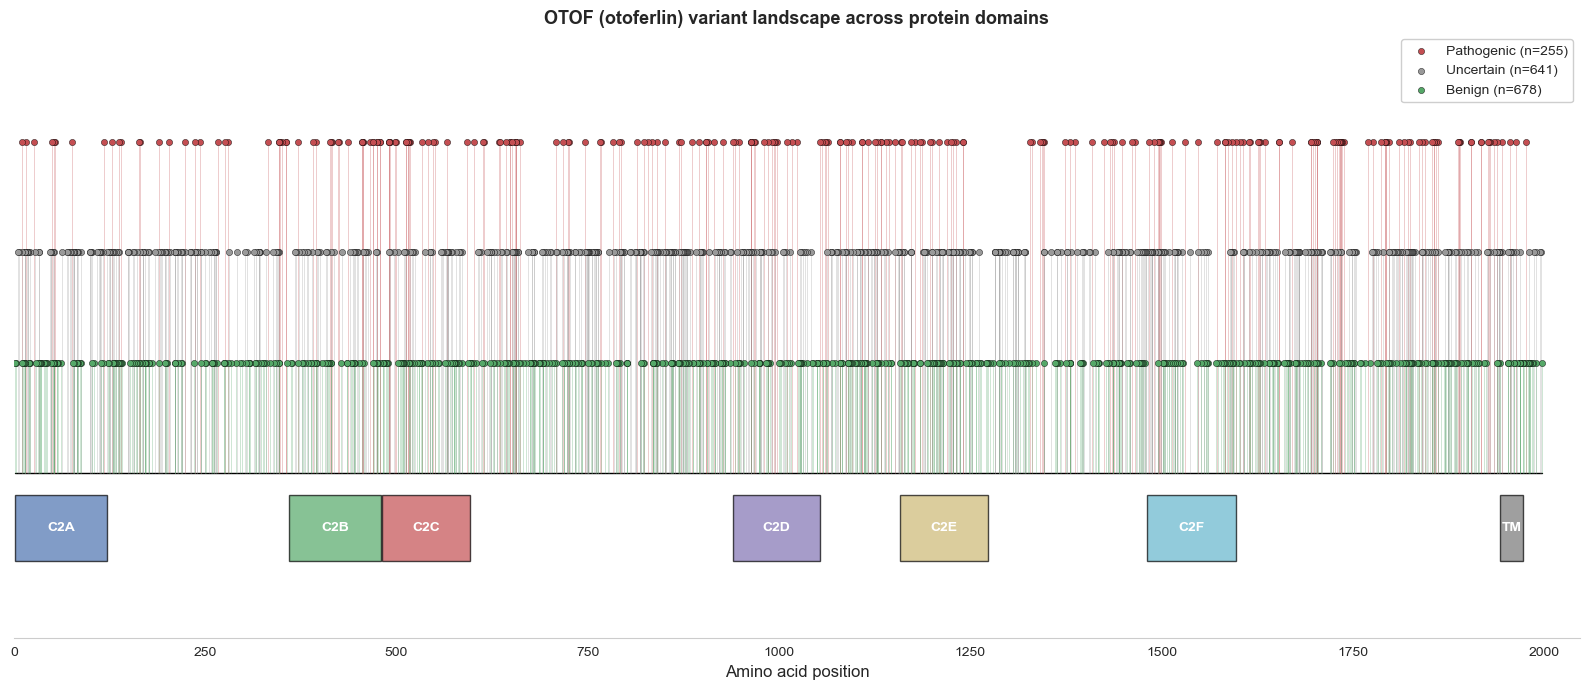

In [6]:
# Filter to variants with valid position and simplified class
plot_df = df.dropna(subset=["aa_position"]).copy()
plot_df = plot_df[plot_df["simplified_class"].isin(["Pathogenic", "Benign", "Uncertain"])]

# Color map
class_colors = {
    "Pathogenic": "#C44E52",
    "Benign": "#55A868",
    "Uncertain": "#999999",
}

# Set up figure
fig, ax = plt.subplots(figsize=(16, 7))

# Plot domains as colored rectangles at the bottom
domain_y = -0.8
domain_height = 0.6
for d in domains:
    rect = patches.Rectangle(
        (d["start"], domain_y), d["end"] - d["start"], domain_height,
        linewidth=1, edgecolor="black", facecolor=d["color"], alpha=0.7
    )
    ax.add_patch(rect)
    # Label inside the domain
    center = (d["start"] + d["end"]) / 2
    ax.text(center, domain_y + domain_height / 2, d["name"],
            ha="center", va="center", fontsize=10, fontweight="bold", color="white")

# Backbone line (the protein)
ax.plot([1, PROTEIN_LENGTH], [0, 0], color="black", linewidth=1, zorder=1)

# Plot variants as lollipops
# Stack variants by class: pathogenic top, uncertain middle, benign bottom
class_order = ["Pathogenic", "Uncertain", "Benign"]
class_y_offset = {"Pathogenic": 3, "Uncertain": 2, "Benign": 1}

for cls in class_order:
    subset = plot_df[plot_df["simplified_class"] == cls]
    positions = subset["aa_position"].values
    y_value = class_y_offset[cls]
    # Stem
    for pos in positions:
        ax.plot([pos, pos], [0, y_value], color=class_colors[cls], linewidth=0.4, alpha=0.5, zorder=2)
    # Marker (lollipop head)
    ax.scatter(positions, [y_value] * len(positions),
               s=20, color=class_colors[cls], edgecolor="black",
               linewidth=0.3, zorder=3, label=f"{cls} (n={len(positions)})")

# Axes setup
ax.set_xlim(0, PROTEIN_LENGTH + 50)
ax.set_ylim(-1.5, 4)
ax.set_xlabel("Amino acid position", fontsize=12)
ax.set_yticks([])
ax.set_title("OTOF (otoferlin) variant landscape across protein domains", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10, framealpha=0.95)
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/otof_lollipop_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [7]:
# Pathogenic density per domain (P/LP per aa)
print("Pathogenic variant density per domain:")
print("=" * 60)

for d in domains:
    domain_name = d["name"]
    domain_length = d["end"] - d["start"] + 1
    n_pathogenic = len(plot_df[(plot_df["domain"] == domain_name) & (plot_df["simplified_class"] == "Pathogenic")])
    density = n_pathogenic / domain_length
    print(f"  {domain_name:6s} ({domain_length:4d} aa): {n_pathogenic:3d} pathogenic --> density = {density:.4f} per aa")

# Linker regions (everything outside domains)
linker_pathogenic = len(plot_df[(plot_df["domain"] == "Linker") & (plot_df["simplified_class"] == "Pathogenic")])
total_domain_aa = sum(d["end"] - d["start"] + 1 for d in domains)
linker_length = PROTEIN_LENGTH - total_domain_aa
linker_density = linker_pathogenic / linker_length
print(f"\n  {'Linker':6s} ({linker_length:4d} aa): {linker_pathogenic:3d} pathogenic --> density = {linker_density:.4f} per aa")

Pathogenic variant density per domain:
  C2A    ( 122 aa):   8 pathogenic --> density = 0.0656 per aa
  C2B    ( 121 aa):  20 pathogenic --> density = 0.1653 per aa
  C2C    ( 116 aa):  18 pathogenic --> density = 0.1552 per aa
  C2D    ( 115 aa):  18 pathogenic --> density = 0.1565 per aa
  C2E    ( 116 aa):  15 pathogenic --> density = 0.1293 per aa
  C2F    ( 117 aa):  15 pathogenic --> density = 0.1282 per aa
  TM     (  32 aa):   3 pathogenic --> density = 0.0938 per aa

  Linker (1258 aa): 158 pathogenic --> density = 0.1256 per aa
